<a href="https://colab.research.google.com/github/kimshy22/AI-Battery-SOH-Monitoring/blob/main/NASA_B0007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
TensorFlow version: 2.19.0


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [65]:


data_path = "/content/drive/MyDrive/NASA_DATA_SCRIPTS/B007_data/processed_B0007_cycle_level.csv"

df = pd.read_csv(data_path)

print("Loaded dataset shape:", df.shape)
print("Columns found:")
print(df.columns.tolist())

display(df.head())

Loaded dataset shape: (168, 33)
Columns found:
['battery_id', 'cycle_id', 'config_name', 'event_id', 'event_type', 'valid_for_direct_soh', 'row_mode', 'measured_capacity_ah', 'corrected_capacity_ah', 'estimated_full_capacity_ah', 'reference_capacity_ah', 'soh_percent', 'soh_percent_smoothed', 'soh_status', 'duration_s', 'num_rows', 'start_time_s', 'end_time_s', 'start_voltage_v', 'end_voltage_v', 'min_voltage_v', 'max_voltage_v', 'voltage_drop_v', 'avg_discharge_current_a', 'avg_charge_current_a', 'avg_temperature_c', 'soc_start', 'soc_end', 'soc_window', 'needs_soc_window_correction', 'notes', 'capacity_ratio', 'current_c_rate']


,battery_id,cycle_id,config_name,event_id,event_type,valid_for_direct_soh,row_mode,measured_capacity_ah,corrected_capacity_ah,estimated_full_capacity_ah,...,avg_discharge_current_a,avg_charge_current_a,avg_temperature_c,soc_start,soc_end,soc_window,needs_soc_window_correction,notes,capacity_ratio,current_c_rate
0,B0007,2,nasa_b0007,2,full_discharge,True,discharge,1.918465,1.918465,1.918465,...,1.990169,0.0,32.375164,NaN,NaN,NaN,False,Looks like a full discharge event.,0.959233,0.995085
1,B0007,4,nasa_b0007,5,full_discharge,True,discharge,1.908111,1.908111,1.908111,...,1.989754,0.0,32.505157,NaN,NaN,NaN,False,Looks like a full discharge event.,0.954055,0.994877
2,B0007,6,nasa_b0007,8,full_discharge,True,discharge,1.908103,1.908103,1.908103,...,1.989869,0.0,32.471508,NaN,NaN,NaN,False,Looks like a full discharge event.,0.954052,0.994935
3,B0007,8,nasa_b0007,11,full_discharge,True,discharge,1.908258,1.908258,1.908258,...,1.989920,0.0,32.360627,NaN,NaN,NaN,False,Looks like a full discharge event.,0.954129,0.994960
4,B0007,10,nasa_b0007,14,full_discharge,True,discharge,1.906847,1.906847,1.906847,...,1.989604,0.0,32.270931,NaN,NaN,NaN,False,Looks like a full discharge event.,0.953423,0.994802


In [66]:
# =========================
# BATTERY SELECTION AND FEATURE ENGINEERING
# =========================

battery_id = "B0007"

# Reload original file fresh to avoid using an already-empty df
data_path = "/content/drive/MyDrive/NASA_DATA_SCRIPTS/B007_data/processed_B0007_cycle_level.csv"
df = pd.read_csv(data_path)

print("Original loaded shape:", df.shape)
print("Battery IDs available:", df["battery_id"].unique())

# Keep only B0007
df = df[df["battery_id"] == battery_id].copy()

print("Shape after selecting B0007:", df.shape)

# Safety check
if df.empty:
    raise ValueError(
        f"No rows found for battery_id={battery_id}. "
        f"Available battery IDs are: {pd.read_csv(data_path)['battery_id'].unique()}"
    )

# Sort by cycle order
df = df.sort_values("cycle_id").reset_index(drop=True)

# If reference_capacity_ah is missing, hard-code NASA reference capacity = 2.0 Ah
if "reference_capacity_ah" not in df.columns:
    df["reference_capacity_ah"] = 2.0
    print("reference_capacity_ah column was missing, so NASA reference capacity 2.0 Ah was added.")
else:
    df["reference_capacity_ah"] = df["reference_capacity_ah"].fillna(2.0)
    print("reference_capacity_ah column found. Missing values filled with 2.0 Ah if any.")

# Normalized capacity feature
df["capacity_ratio"] = df["corrected_capacity_ah"] / df["reference_capacity_ah"]

# Normalized current stress feature
df["current_c_rate"] = df["avg_discharge_current_a"].abs() / df["reference_capacity_ah"]

# Current SOH ratio used as input
df["soh_ratio_current"] = df["soh_percent_smoothed"] / 100.0

# Next-cycle SOH ratio used as prediction target
df["target_soh_ratio"] = df["soh_ratio_current"].shift(-1)

# Drop ONLY rows where model-required columns are missing
required_engineering_cols = [
    "cycle_id",
    "capacity_ratio",
    "current_c_rate",
    "soh_ratio_current",
    "target_soh_ratio",
    "duration_s",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v"
]

print("\nMissing values before final cleaning:")
print(df[required_engineering_cols].isna().sum())

df = df.dropna(subset=required_engineering_cols).reset_index(drop=True)

print("\nSelected battery:", battery_id)
print("Data prepared. Shape:", df.shape)
print("Cycle range:", df["cycle_id"].min(), "to", df["cycle_id"].max())

print("\nPreview of engineered features:")
display(df[
    [
        "cycle_id",
        "corrected_capacity_ah",
        "reference_capacity_ah",
        "capacity_ratio",
        "avg_discharge_current_a",
        "current_c_rate",
        "soh_percent_smoothed",
        "soh_ratio_current",
        "target_soh_ratio"
    ]
].head(10))

Original loaded shape: (168, 33)
Battery IDs available: ['B0007']
Shape after selecting B0007: (168, 33)
reference_capacity_ah column found. Missing values filled with 2.0 Ah if any.

Missing values before final cleaning:
cycle_id             0
capacity_ratio       0
current_c_rate       0
soh_ratio_current    0
target_soh_ratio     1
duration_s           0
avg_temperature_c    0
start_voltage_v      0
end_voltage_v        0
dtype: int64

Selected battery: B0007
Data prepared. Shape: (167, 35)
Cycle range: 2 to 612

Preview of engineered features:


,cycle_id,corrected_capacity_ah,reference_capacity_ah,capacity_ratio,avg_discharge_current_a,current_c_rate,soh_percent_smoothed,soh_ratio_current,target_soh_ratio
0,2,1.918465,2.0,0.959233,1.990169,0.995085,95.923264,0.959233,0.954832
1,4,1.908111,2.0,0.954055,1.989754,0.994877,95.483190,0.954832,0.954169
2,6,1.908103,2.0,0.954052,1.989869,0.994935,95.416877,0.954169,0.954135
3,8,1.908258,2.0,0.954129,1.989920,0.994960,95.413493,0.954135,0.953530
4,10,1.906847,2.0,0.953423,1.989604,0.994802,95.353002,0.953530,0.949282
5,12,1.897065,2.0,0.948532,1.989797,0.994898,94.928211,0.949282,0.948287
6,14,1.896223,2.0,0.948112,1.989603,0.994801,94.828720,0.948287,0.948812
7,16,1.897810,2.0,0.948905,1.989511,0.994756,94.881221,0.948812,0.948533
8,18,1.896967,2.0,0.948484,1.989658,0.994829,94.853289,0.948533,0.948711
9,20,1.897486,2.0,0.948743,1.989688,0.994844,94.871139,0.948711,0.948705


In [83]:


feature_cols = [
    "capacity_ratio",
    "soh_ratio_current",
    "duration_s",
    "current_c_rate",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v"
]

target_col = "target_soh_ratio"

print("Feature columns:")
print(feature_cols)

print("\nTarget column:")
print(target_col)

Feature columns:
['capacity_ratio', 'soh_ratio_current', 'duration_s', 'current_c_rate', 'avg_temperature_c', 'start_voltage_v', 'end_voltage_v']

Target column:
target_soh_ratio


In [84]:


required_cols = ["battery_id", "cycle_id"] + feature_cols + [target_col]

print("Missing values before cleaning:")
print(df[required_cols].isna().sum())

df = df.dropna(subset=required_cols).copy()
df = df.sort_values("cycle_id").reset_index(drop=True)

print("\nDataset shape after cleaning:", df.shape)

display(df[required_cols].head())

Missing values before cleaning:
battery_id           0
cycle_id             0
capacity_ratio       0
soh_ratio_current    0
duration_s           0
current_c_rate       0
avg_temperature_c    0
start_voltage_v      0
end_voltage_v        0
target_soh_ratio     0
dtype: int64

Dataset shape after cleaning: (167, 35)


,battery_id,cycle_id,capacity_ratio,soh_ratio_current,duration_s,current_c_rate,avg_temperature_c,start_voltage_v,end_voltage_v,target_soh_ratio
0,B0007,2,0.959233,0.959233,3451.375,0.995085,32.375164,3.985606,2.145976,0.954832
1,B0007,4,0.954055,0.954832,3433.250,0.994877,32.505157,3.990235,2.111017,0.954169
2,B0007,6,0.954052,0.954169,3433.093,0.994935,32.471508,3.992171,2.025109,0.954135
3,B0007,8,0.954129,0.954135,3433.282,0.994960,32.360627,3.993218,1.922542,0.953530
4,B0007,10,0.953423,0.953530,3431.328,0.994802,32.270931,3.993959,1.871159,0.949282


In [85]:


train_fraction = 0.75
val_fraction = 0.15
test_fraction = 0.10

n = len(df)

train_end = int(n * train_fraction)
val_end = int(n * (train_fraction + val_fraction))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Total rows:", n)
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nCycle ranges:")
print("Train:", train_df["cycle_id"].min(), "to", train_df["cycle_id"].max())
print("Val  :", val_df["cycle_id"].min(), "to", val_df["cycle_id"].max())
print("Test :", test_df["cycle_id"].min(), "to", test_df["cycle_id"].max())

Total rows: 167
Train shape: (125, 35)
Validation shape: (25, 35)
Test shape: (17, 35)

Cycle ranges:
Train: 2 to 449
Val  : 453 to 545
Test : 548 to 612


In [86]:


def describe_split(name, split_df):
    print(f"\n{name} split")
    print("Rows:", len(split_df))
    print("Cycle range:", split_df["cycle_id"].min(), "to", split_df["cycle_id"].max())
    print("SOH min:", split_df["soh_percent_smoothed"].min())
    print("SOH max:", split_df["soh_percent_smoothed"].max())
    print("SOH mean:", split_df["soh_percent_smoothed"].mean())

describe_split("Train", train_df)
describe_split("Validation", val_df)
describe_split("Test", test_df)


Train split
Rows: 125
Cycle range: 2 to 449
SOH min: 76.40658839009673
SOH max: 95.92326359352704
SOH mean: 86.55852481739348

Validation split
Rows: 25
Cycle range: 453 to 545
SOH min: 73.02291989229667
SOH max: 76.1426351790052
SOH mean: 74.51777563658854

Test split
Rows: 17
Cycle range: 548 to 612
SOH min: 71.27107511837856
SOH max: 73.76031209418993
SOH mean: 72.35795044834413


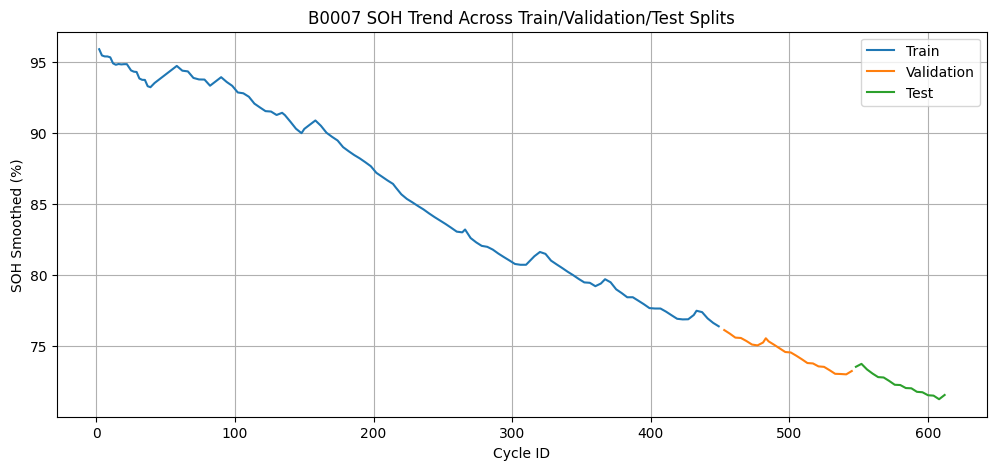

In [87]:

plt.figure(figsize=(12, 5))

plt.plot(train_df["cycle_id"], train_df["soh_percent_smoothed"], label="Train")
plt.plot(val_df["cycle_id"], val_df["soh_percent_smoothed"], label="Validation")
plt.plot(test_df["cycle_id"], test_df["soh_percent_smoothed"], label="Test")

plt.xlabel("Cycle ID")
plt.ylabel("SOH Smoothed (%)")
plt.title("B0007 SOH Trend Across Train/Validation/Test Splits")
plt.legend()
plt.grid(True)
plt.show()

In [88]:


feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit scalers only on training data
feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[target_col]])

# Make copies before scaling
train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

# Keep original cycle IDs before scaling
# These will be used only for displaying results clearly
train_df_scaled["cycle_id_original"] = train_df["cycle_id"].values
val_df_scaled["cycle_id_original"] = val_df["cycle_id"].values
test_df_scaled["cycle_id_original"] = test_df["cycle_id"].values

# Scale feature columns for model training
train_df_scaled[feature_cols] = feature_scaler.transform(train_df[feature_cols])
val_df_scaled[feature_cols] = feature_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = feature_scaler.transform(test_df[feature_cols])

# Scale target column
train_df_scaled[target_col] = target_scaler.transform(train_df[[target_col]])
val_df_scaled[target_col] = target_scaler.transform(val_df[[target_col]])
test_df_scaled[target_col] = target_scaler.transform(test_df[[target_col]])

print("Scaling complete.")

print("\nCheck cycle ID before and after scaling:")

display(train_df_scaled[
    [
        "cycle_id_original",
        "cycle_id",
        "capacity_ratio",
        "current_c_rate",
        target_col
    ]
].head())

Scaling complete.

Check cycle ID before and after scaling:


,cycle_id_original,cycle_id,capacity_ratio,current_c_rate,target_soh_ratio
0,2,2,1.000000,0.956496,1.000000
1,4,4,0.973530,0.595096,0.996571
2,6,6,0.973512,0.695262,0.996396
3,8,8,0.973907,0.739106,0.993269
4,10,10,0.970299,0.464091,0.971305


In [89]:


def build_sequences(dataframe, feature_cols, target_col, window_size=10, horizon=1):
    """
    Converts cycle-level data into LSTM sequences.

    The model uses scaled features.
    But the metadata table uses cycle_id_original so we can see the real cycle numbers.
    """

    X = []
    y = []
    meta = []

    # Sort using the real cycle number
    dataframe = dataframe.sort_values("cycle_id_original").reset_index(drop=True)

    # These are the scaled values used by the LSTM
    feature_array = dataframe[feature_cols].values
    target_array = dataframe[target_col].values

    # These are the real cycle numbers used only for display
    cycle_ids = dataframe["cycle_id_original"].values

    max_start = len(dataframe) - window_size - horizon + 1

    if max_start <= 0:
        raise ValueError(
            f"Not enough data to build sequences. "
            f"Rows={len(dataframe)}, window_size={window_size}, horizon={horizon}"
        )

    for i in range(max_start):
        x_seq = feature_array[i:i + window_size]
        y_target = target_array[i + window_size + horizon - 1]

        X.append(x_seq)
        y.append(y_target)

        meta.append({
            "input_start_cycle": int(cycle_ids[i]),
            "input_end_cycle": int(cycle_ids[i + window_size - 1]),
            "target_cycle": int(cycle_ids[i + window_size + horizon - 1])
        })

    X = np.array(X)
    y = np.array(y).reshape(-1, 1)
    meta = pd.DataFrame(meta)

    return X, y, meta

In [90]:


WINDOW_SIZE = 4
HORIZON = 1

X_train, y_train, meta_train = build_sequences(
    train_df_scaled,
    feature_cols,
    target_col,
    window_size=WINDOW_SIZE,
    horizon=HORIZON
)

X_val, y_val, meta_val = build_sequences(
    val_df_scaled,
    feature_cols,
    target_col,
    window_size=WINDOW_SIZE,
    horizon=HORIZON
)

X_test, y_test, meta_test = build_sequences(
    test_df_scaled,
    feature_cols,
    target_col,
    window_size=WINDOW_SIZE,
    horizon=HORIZON
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

display(meta_train.head())

X_train: (121, 4, 7)
y_train: (121, 1)
X_val: (21, 4, 7)
y_val: (21, 1)
X_test: (13, 4, 7)
y_test: (13, 1)


,input_start_cycle,input_end_cycle,target_cycle
0,2,8,10
1,4,10,12
2,6,12,14
3,8,14,16
4,10,16,18


In [100]:


def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape, return_sequences=False),
        Dropout(0.3),
        Dense(8, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


input_shape = (X_train.shape[1], X_train.shape[2])

model = build_lstm_model(input_shape)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,393 (21.07 KB)

 Trainable params: 5,393 (21.07 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:


callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=30,
        min_delta=1e-5,
        restore_best_weights=True,
        start_from_epoch=40
    ),
    ModelCheckpoint(
        filepath="best_lstm_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("Training complete.")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.4624 - mae: 0.5709 - val_loss: 0.0304 - val_mae: 0.1698
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2413 - mae: 0.3966 - val_loss: 0.0665 - val_mae: 0.2556
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1294 - mae: 0.2908 - val_loss: 0.1066 - val_mae: 0.3250
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0794 - mae: 0.2438 - val_loss: 0.1275 - val_mae: 0.3560
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0706 - mae: 0.2271 - val_loss: 0.1065 - val_mae: 0.3251
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0493 - mae: 0.1856 - val_loss: 0.0692 - val_mae: 0.2618
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0326 - mae: 0.1525 - val_loss: 0.0373 - val_mae: 0.1914
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0303 - mae: 0.1488 - val_loss: 0.0181 - val_mae: 0.1322
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0208 - mae: 

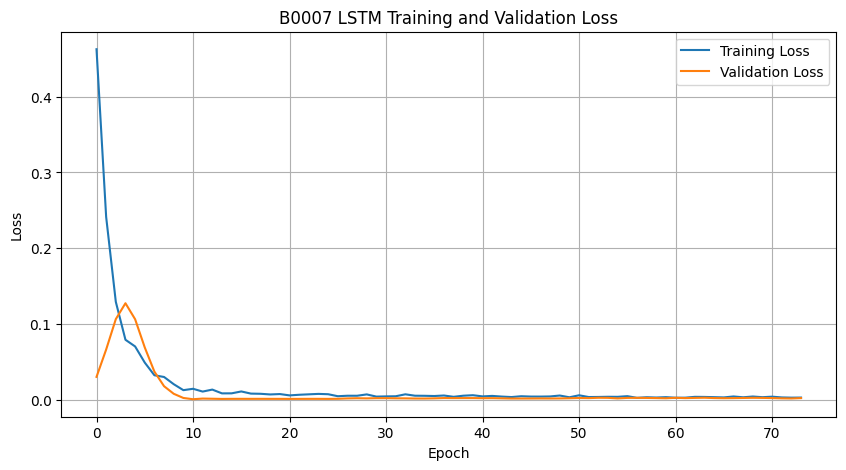

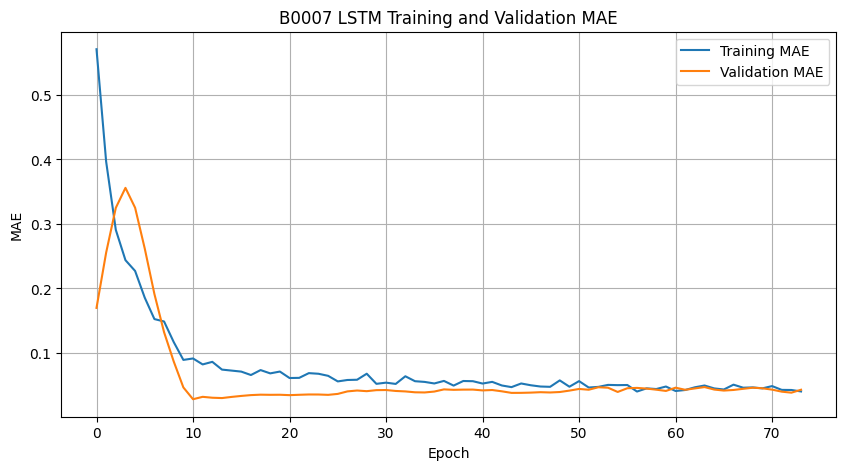

In [93]:


plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("B0007 LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("B0007 LSTM Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [94]:


y_pred_scaled = model.predict(X_test)

# Inverse transform back to target_soh_ratio
y_test_real_ratio = target_scaler.inverse_transform(y_test)
y_pred_real_ratio = target_scaler.inverse_transform(y_pred_scaled)

# Convert SOH ratio back to SOH percentage
y_test_real_soh = y_test_real_ratio.flatten() * 100.0
y_pred_real_soh = y_pred_real_ratio.flatten() * 100.0

mae = mean_absolute_error(y_test_real_soh, y_pred_real_soh)
rmse = np.sqrt(mean_squared_error(y_test_real_soh, y_pred_real_soh))
r2 = r2_score(y_test_real_soh, y_pred_real_soh)

print(f"Test MAE  : {mae:.4f} % SOH")
print(f"Test RMSE : {rmse:.4f} % SOH")
print(f"Test R^2  : {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
Test MAE  : 1.4373 % SOH
Test RMSE : 1.4592 % SOH
Test R^2  : -10.7988


,input_start_cycle,input_end_cycle,target_cycle,actual_soh,predicted_soh,abs_error
0,548,560,564,72.802424,73.886475,1.084051
1,552,564,568,72.559225,73.665298,1.106073
2,556,568,572,72.289338,73.706932,1.417594
3,560,572,576,72.271075,73.612671,1.341596
4,564,576,580,72.057715,73.383453,1.325739


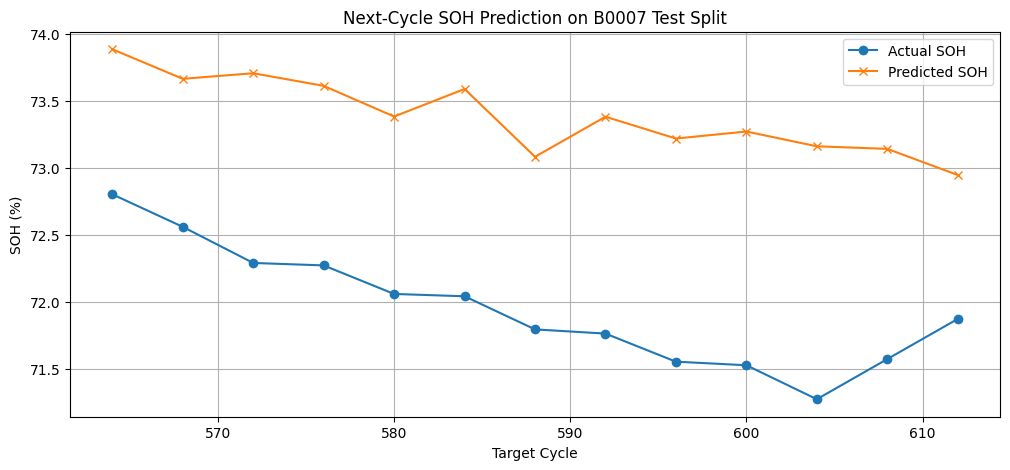

In [95]:


results_df = meta_test.copy()

results_df["actual_soh"] = y_test_real_soh
results_df["predicted_soh"] = y_pred_real_soh
results_df["abs_error"] = np.abs(results_df["actual_soh"] - results_df["predicted_soh"])

display(results_df.head())

plt.figure(figsize=(12, 5))

plt.plot(
    results_df["target_cycle"],
    results_df["actual_soh"],
    label="Actual SOH",
    marker="o"
)

plt.plot(
    results_df["target_cycle"],
    results_df["predicted_soh"],
    label="Predicted SOH",
    marker="x"
)

plt.xlabel("Target Cycle")
plt.ylabel("SOH (%)")
plt.title("Next-Cycle SOH Prediction on B0007 Test Split")
plt.legend()
plt.grid(True)
plt.show()

In [101]:


baseline_predictions = []

for _, row in results_df.iterrows():
    last_input_cycle = row["input_end_cycle"]

    last_soh_value = df.loc[
        df["cycle_id"] == last_input_cycle,
        "soh_percent_smoothed"
    ].values[0]

    baseline_predictions.append(last_soh_value)

results_df["baseline_predicted_soh"] = baseline_predictions
results_df["baseline_abs_error"] = np.abs(
    results_df["actual_soh"] - results_df["baseline_predicted_soh"]
)

print("LSTM MAE:", results_df["abs_error"].mean())
print("Baseline MAE:", results_df["baseline_abs_error"].mean())

display(results_df[
    [
        "input_start_cycle",
        "input_end_cycle",
        "target_cycle",
        "actual_soh",
        "predicted_soh",
        "abs_error",
        "baseline_predicted_soh",
        "baseline_abs_error"
    ]
])

LSTM MAE: 1.4372717670546886
Baseline MAE: 0.2890332878906933


,input_start_cycle,input_end_cycle,target_cycle,actual_soh,predicted_soh,abs_error,baseline_predicted_soh,baseline_abs_error
0,548,560,564,72.802424,73.886475,1.084051,73.078227,0.275803
1,552,564,568,72.559225,73.665298,1.106073,72.829104,0.269878
2,556,568,572,72.289338,73.706932,1.417594,72.802424,0.513086
3,560,572,576,72.271075,73.612671,1.341596,72.559225,0.288150
4,564,576,580,72.057715,73.383453,1.325739,72.289338,0.231623
5,568,580,584,72.040392,73.589363,1.548971,72.271075,0.230683
6,572,584,588,71.792865,73.082848,1.289983,72.057715,0.264850
7,576,588,592,71.761519,73.381950,1.620431,72.040392,0.278873
8,580,592,596,71.551644,73.219116,1.667473,71.792865,0.241221
9,584,596,600,71.524949,73.271461,1.746512,71.761519,0.236570


In [102]:
# =========================
# ANALYSIS: TARGET CYCLE DETAILS
# =========================

target_details = df[
    [
        "cycle_id",
        "corrected_capacity_ah",
        "capacity_ratio",
        "soh_percent_smoothed",
        "soh_ratio_current",
        "duration_s",
        "current_c_rate",
        "avg_temperature_c",
        "start_voltage_v",
        "end_voltage_v"
    ]
].copy()

target_details = target_details.rename(columns={"cycle_id": "target_cycle"})

results_with_details = results_df.merge(target_details, on="target_cycle", how="left")

display(results_with_details)

,input_start_cycle,input_end_cycle,target_cycle,actual_soh,predicted_soh,abs_error,baseline_predicted_soh,baseline_abs_error,corrected_capacity_ah,capacity_ratio,soh_percent_smoothed,soh_ratio_current,duration_s,current_c_rate,avg_temperature_c,start_voltage_v,end_voltage_v
0,548,560,564,72.802424,73.886475,1.084051,73.078227,0.275803,1.455703,0.727851,72.829104,0.728291,2623.875,0.994781,31.974453,3.987870,2.166437
1,552,564,568,72.559225,73.665298,1.106073,72.829104,0.269878,1.455954,0.727977,72.802424,0.728024,2624.391,0.994758,31.980021,3.987080,1.987194
2,556,568,572,72.289338,73.706932,1.417594,72.802424,0.513086,1.450326,0.725163,72.559225,0.725592,2614.125,0.994784,31.975637,3.987564,2.131417
3,560,572,576,72.271075,73.612671,1.341596,72.559225,0.288150,1.444834,0.722417,72.289338,0.722893,2604.360,0.994724,31.922039,3.986628,2.188996
4,564,576,580,72.057715,73.383453,1.325739,72.289338,0.231623,1.445357,0.722679,72.271075,0.722711,2605.203,0.994732,31.943957,3.985702,2.032246
5,568,580,584,72.040392,73.589363,1.548971,72.271075,0.230683,1.440401,0.720201,72.057715,0.720577,2596.250,0.994752,31.986618,3.986332,2.169513
6,572,584,588,71.792865,73.082848,1.289983,72.057715,0.264850,1.440747,0.720373,72.040392,0.720404,2596.750,0.994770,32.046275,3.985291,1.991798
7,576,588,592,71.761519,73.381950,1.620431,72.040392,0.278873,1.434984,0.717492,71.792865,0.717929,2586.593,0.994702,32.076504,3.985381,2.153449
8,580,592,596,71.551644,73.219116,1.667473,71.792865,0.241221,1.435120,0.717560,71.761519,0.717615,2586.703,0.994705,32.020389,3.984628,2.010157
9,584,596,600,71.524949,73.271461,1.746512,71.761519,0.236570,1.430292,0.715146,71.551644,0.715516,2578.016,0.994734,32.011754,3.985053,2.132719


In [103]:
# =========================
# SAVE ARTIFACTS
# =========================

save_dir = "/content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "b0007_lstm_model.keras")
weights_path = os.path.join(save_dir, "b0007_lstm_model.weights.h5")
feature_scaler_path = os.path.join(save_dir, "feature_scaler.pkl")
target_scaler_path = os.path.join(save_dir, "target_scaler.pkl")
config_path = os.path.join(save_dir, "training_config.json")
results_path = os.path.join(save_dir, "test_predictions.csv")

# Save full model and weights
model.save(model_path)
model.save_weights(weights_path)

# Save scalers
joblib.dump(feature_scaler, feature_scaler_path)
joblib.dump(target_scaler, target_scaler_path)

# Save results
results_df.to_csv(results_path, index=False)

# Save configuration
config = {
    "model_name": "B0007_LCO_LSTM_normalized_features",
    "battery_id": battery_id,
    "chemistry": "LCO",
    "dataset": "NASA Ames Prognostics Center Battery Dataset",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "feature_cols": feature_cols,
    "target_col": target_col,
    "target_display": "Predictions are converted to SOH percent by multiplying target_soh_ratio by 100",
    "reference_capacity_ah": 2.0,
    "feature_engineering": {
        "capacity_ratio": "corrected_capacity_ah / reference_capacity_ah",
        "current_c_rate": "abs(avg_discharge_current_a) / reference_capacity_ah"
    },
    "target_engineering": {
        "target_soh_ratio": "soh_percent_smoothed / 100"
    },
    "split_strategy": "single_battery_chronological_75_15_10",
    "train_fraction": train_fraction,
    "val_fraction": val_fraction,
    "test_fraction": test_fraction,
    "metrics": {
        "test_mae_percent_soh": float(mae),
        "test_rmse_percent_soh": float(rmse),
        "test_r2": float(r2)
    }
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Saved artifacts to:", save_dir)
print("Model:", model_path)
print("Weights:", weights_path)
print("Feature scaler:", feature_scaler_path)
print("Target scaler:", target_scaler_path)
print("Config:", config_path)
print("Results:", results_path)

Saved artifacts to: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts
Model: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/b0007_lstm_model.keras
Weights: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/b0007_lstm_model.weights.h5
Feature scaler: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/feature_scaler.pkl
Target scaler: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/target_scaler.pkl
Config: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/training_config.json
Results: /content/drive/MyDrive/B007_data/B0007_lstm_normalized_artifacts/test_predictions.csv


In [104]:


print("Files saved in artifact folder:")
for file_name in os.listdir(save_dir):
    print("-", file_name)

Files saved in artifact folder:
- b0007_lstm_model.keras
- b0007_lstm_model.weights.h5
- feature_scaler.pkl
- target_scaler.pkl
- test_predictions.csv
- training_config.json
